# POIs del Corredor — Av. Roosevelt · Overture Maps
**ITT Cali Inteligente · Equipo de Gobierno de Datos**

Descarga todos los puntos de interés (negocios, servicios, equipamiento) dentro del polígono de intervención de Av. Roosevelt usando Overture Maps — dataset open data de Meta, Microsoft, Amazon y TomTom.

**Ventajas sobre Google Maps:**
- Sin API Key, sin costo, sin solicitud
- Datos descargables en GeoJSON
- Actualización mensual
- Incluye lugares con presencia digital aunque no tengan matrícula mercantil

**Instrucciones:** Ejecutar celdas en orden (Shift + Enter).

In [1]:
# Celda 1 — Instalar dependencias
!pip install overturemaps geopandas shapely pandas matplotlib -q
print('Dependencias instaladas.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 23.7 MB/s eta 0:00:00
Dependencias instaladas.


In [2]:
# Celda 2 — Definir polígono de Roosevelt
# Bounding box del buffer 100m de Av. Roosevelt (GeoJSON de Jorge)

# Formato Overture: xmin, ymin, xmax, ymax (lon_min, lat_min, lon_max, lat_max)
BBOX = (
    -76.54235038,  # lon min (oeste)
     3.42514711,   # lat min (sur)
    -76.53685514,  # lon max (este)
     3.43761420    # lat max (norte)
)

POLIGONO = 'Av. Roosevelt - Buffer 100m'

print(f'Polígono: {POLIGONO}')
print(f'Bounding box: {BBOX}')
print(f'Área aprox: 42.9 ha')

Polígono: Av. Roosevelt - Buffer 100m
Bounding box: (-76.54235038, 3.42514711, -76.53685514, 3.4376142)
Área aprox: 42.9 ha


In [3]:
# Celda 3 — Descargar POIs desde Overture Maps
import subprocess
import os

xmin, ymin, xmax, ymax = BBOX

cmd = [
    'overturemaps', 'download',
    f'--bbox={xmin},{ymin},{xmax},{ymax}',
    '-f', 'geojson',
    '--type=place',
    '-o', 'roosevelt_overture_poi_raw.geojson'
]

print('Descargando POIs de Overture Maps...')
print(f'Área: {POLIGONO}')
print()

result = subprocess.run(cmd, capture_output=True, text=True)

if result.returncode == 0:
    size = os.path.getsize('roosevelt_overture_poi_raw.geojson') / 1024
    print(f'Descarga exitosa — archivo: {size:.1f} KB')
else:
    print(f'Error: {result.stderr}')

Descargando POIs de Overture Maps...
Área: Av. Roosevelt - Buffer 100m

Descarga exitosa — archivo: 1065.6 KB


In [4]:
# Celda 4 — Cargar y explorar los POIs descargados
import geopandas as gpd
import pandas as pd

gdf = gpd.read_file('roosevelt_overture_poi_raw.geojson')

print(f'=== POIs DESCARGADOS ===')
print(f'Total lugares: {len(gdf)}')
print()
print(f'Columnas disponibles:')
for col in gdf.columns:
    print(f'  - {col}')

=== POIs DESCARGADOS ===
Total lugares: 896

Columnas disponibles:
  - id
  - categories
  - confidence
  - websites
  - emails
  - socials
  - phones
  - brand
  - addresses
  - names
  - sources
  - operating_status
  - basic_category
  - taxonomy
  - version
  - geometry


In [5]:
# Celda 5 — Filtrar al polígono exacto de Jorge
from google.colab import files
from shapely.geometry import Point

print('Sube el GeoJSON del polígono exacto de Roosevelt...')
uploaded = files.upload()

gdf_poligono = gpd.read_file('Geojson_tramos_Roosevelt_Buffer_100.geojson')
poligono = gdf_poligono.geometry.iloc[0]

# Asegurar mismo CRS
if gdf.crs is None:
    gdf = gdf.set_crs('EPSG:4326')
gdf_poligono = gdf_poligono.to_crs('EPSG:4326')

# Filtrar por polígono exacto
gdf_filtrado = gdf[gdf.geometry.within(poligono)].copy()

print(f'POIs antes del filtro (bounding box): {len(gdf)}')
print(f'POIs dentro del polígono exacto: {len(gdf_filtrado)}')
print(f'POIs descartados: {len(gdf) - len(gdf_filtrado)}')

Sube el GeoJSON del polígono exacto de Roosevelt...


Saving Geojson_tramos_Roosevelt_Buffer_100.geojson to Geojson_tramos_Roosevelt_Buffer_100.geojson
POIs antes del filtro (bounding box): 896
POIs dentro del polígono exacto: 474
POIs descartados: 422


In [6]:
# Celda 6 — Ver lista completa de lugares dentro del polígono
import json

def extraer_nombre(row):
    try:
        names = row.get('names', {})
        if isinstance(names, str):
            names = json.loads(names)
        primary = names.get('primary', '')
        if isinstance(primary, list):
            return primary[0] if primary else 'Sin nombre'
        return primary or 'Sin nombre'
    except:
        return 'Sin nombre'

def extraer_categoria(row):
    try:
        cats = row.get('categories', {})
        if isinstance(cats, str):
            cats = json.loads(cats)
        return cats.get('primary', 'sin_categoria')
    except:
        return 'sin_categoria'

def extraer_confianza(row):
    try:
        return round(float(row.get('confidence', 0)), 2)
    except:
        return None

df_lista = pd.DataFrame({
    'nombre': gdf_filtrado.apply(extraer_nombre, axis=1),
    'categoria': gdf_filtrado.apply(extraer_categoria, axis=1),
    'confianza': gdf_filtrado.apply(extraer_confianza, axis=1),
    'lat': gdf_filtrado.geometry.y,
    'lon': gdf_filtrado.geometry.x,
})

print(f'=== LUGARES DENTRO DEL POLÍGONO EXACTO ===')
print(f'Total: {len(df_lista)}')
print()
print('Por categoría:')
print(df_lista['categoria'].value_counts().to_string())
print()
print('Lista completa:')
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_colwidth', 55)
print(df_lista[['nombre','categoria','confianza']].to_string(index=True))

=== LUGARES DENTRO DEL POLÍGONO EXACTO ===
Total: 474

Por categoría:
categoria
restaurant                                              22
sin_categoria                                           16
dentist                                                 14
health_and_medical                                      12
event_planning                                          12
bar                                                     12
motorcycle_dealer                                       11
hotel                                                   11
professional_services                                   11
church_cathedral                                        10
clothing_store                                          10
automotive_repair                                        8
automotive_parts_and_accessories                         8
travel_services                                          7
dance_club                                               7
bakery                             

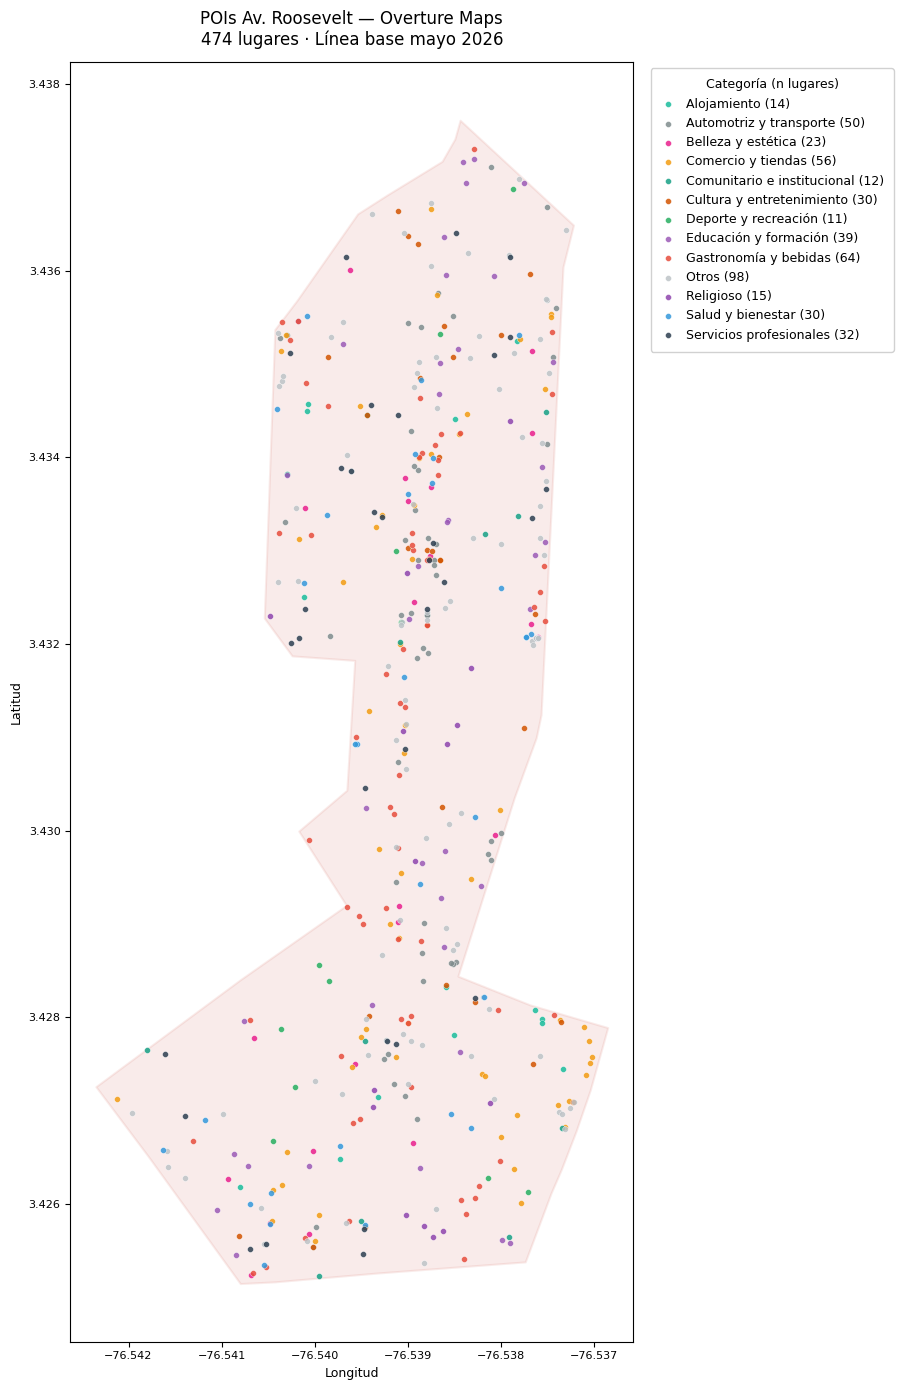

Mapa guardado.

Distribución por macrocategoría:
macrocategoria
Otros                          98
Gastronomía y bebidas          64
Comercio y tiendas             56
Automotriz y transporte        50
Educación y formación          39
Servicios profesionales        32
Salud y bienestar              30
Cultura y entretenimiento      30
Belleza y estética             23
Religioso                      15
Alojamiento                    14
Comunitario e institucional    12
Deporte y recreación           11


In [7]:
# Celda 7B — Mapa mejorado con categorías agrupadas
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Agrupación de categorías en macrocategorías
def agrupar(cat):
    cat = str(cat).lower()
    if any(x in cat for x in ['restaurant','food','bakery','pizza','burger',
                                'chicken','coffee','bar','dessert','ice_cream',
                                'colombian','peruvian','vegetarian','fast_food']):
        return 'Gastronomía y bebidas'
    if any(x in cat for x in ['health','medical','dental','doctor','hospital',
                                'clinic','pharmacy','optician','nursing',
                                'counseling','mental_health','holistic']):
        return 'Salud y bienestar'
    if any(x in cat for x in ['store','shop','supermarket','market','clothing',
                                'electronics','furniture','sporting','jewelry',
                                'beauty_supply','thrift','wholesale','department',
                                'home_goods','candy','grocery','flowers']):
        return 'Comercio y tiendas'
    if any(x in cat for x in ['school','university','college','education',
                                'language','driving_school','dance','music',
                                'yoga','martial_arts','nursing_school','cosmetology']):
        return 'Educación y formación'
    if any(x in cat for x in ['hotel','lodging','hostel','accommodation',
                                'retirement','hostel']):
        return 'Alojamiento'
    if any(x in cat for x in ['professional','financial','insurance','accounting',
                                'marketing','advertising','consulting','technology',
                                'media','b2b','printing','business','legal','lawyer']):
        return 'Servicios profesionales'
    if any(x in cat for x in ['automotive','car','motorcycle','tire','bike',
                                'gas_station','transportation']):
        return 'Automotriz y transporte'
    if any(x in cat for x in ['beauty','spa','salon','barber','hair',
                                'esthetic','cosmetic']):
        return 'Belleza y estética'
    if any(x in cat for x in ['sport','gym','fitness','recreation','basketball',
                                'stadium','arena','active','park']):
        return 'Deporte y recreación'
    if any(x in cat for x in ['church','religious','cathedral','catholic']):
        return 'Religioso'
    if any(x in cat for x in ['community','social','nonprofit','organization',
                                'government','public','association','foundation']):
        return 'Comunitario e institucional'
    if any(x in cat for x in ['art','museum','landmark','historical','event',
                                'concert','entertainment','adult','travel']):
        return 'Cultura y entretenimiento'
    return 'Otros'

df_lista['macrocategoria'] = df_lista['categoria'].apply(agrupar)

# Paleta de colores por macrocategoría
palette = {
    'Gastronomía y bebidas':       '#E74C3C',
    'Salud y bienestar':           '#3498DB',
    'Comercio y tiendas':          '#F39C12',
    'Educación y formación':       '#9B59B6',
    'Alojamiento':                 '#1ABC9C',
    'Servicios profesionales':     '#2C3E50',
    'Automotriz y transporte':     '#7F8C8D',
    'Belleza y estética':          '#E91E8C',
    'Deporte y recreación':        '#27AE60',
    'Religioso':                   '#8E44AD',
    'Comunitario e institucional': '#16A085',
    'Cultura y entretenimiento':   '#D35400',
    'Otros':                       '#BDC3C7',
}

fig, ax = plt.subplots(figsize=(8, 14))

# Polígono
gdf_poligono.to_crs('EPSG:4326').plot(
    ax=ax, color='#CB4335', alpha=0.10,
    edgecolor='#CB4335', linewidth=1.5
)

# POIs por macrocategoría
for mac, grupo in df_lista.groupby('macrocategoria'):
    ax.scatter(
        grupo['lon'], grupo['lat'],
        color=palette.get(mac, '#BDC3C7'),
        s=18, zorder=5, alpha=0.85,
        edgecolors='white', linewidth=0.3,
        label=f"{mac} ({len(grupo)})"
    )

ax.set_title(
    f'POIs Av. Roosevelt — Overture Maps\n'
    f'{len(df_lista)} lugares · Línea base mayo 2026',
    fontsize=12, pad=12
)
ax.set_xlabel('Longitud', fontsize=9)
ax.set_ylabel('Latitud', fontsize=9)
ax.tick_params(labelsize=8)

ax.legend(
    loc='upper left',
    bbox_to_anchor=(1.02, 1),
    fontsize=9,
    framealpha=0.9,
    borderpad=0.8,
    handlelength=1.2,
    title='Categoría (n lugares)',
    title_fontsize=9
)

plt.tight_layout()
plt.savefig('roosevelt_overture_poi_mapa.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Mapa guardado.')

# Resumen por macrocategoría
print()
print('Distribución por macrocategoría:')
print(df_lista['macrocategoria'].value_counts().to_string())

In [8]:
# Celda 8 — Exportar CSV limpio para el datalake
import datetime

df_export = df_lista.copy()
df_export['fecha_extraccion'] = datetime.date.today().isoformat()
df_export['poligono'] = POLIGONO
df_export['fuente'] = 'Overture Maps Foundation'
df_export['momento'] = 'linea_base_pre_intervencion'
df_export['release_overture'] = '2026-04-15'

df_export.to_csv('roosevelt_overture_poi.csv', index=False)

# Guardar GeoJSON filtrado también
gdf_filtrado.to_file('roosevelt_overture_poi.geojson', driver='GeoJSON')

print(f'Exportados:')
print(f'  CSV: roosevelt_overture_poi.csv ({len(df_export)} registros)')
print(f'  GeoJSON: roosevelt_overture_poi.geojson')
print()
print('Columnas del CSV:')
for col in df_export.columns:
    print(f'  - {col}')

Exportados:
  CSV: roosevelt_overture_poi.csv (474 registros)
  GeoJSON: roosevelt_overture_poi.geojson

Columnas del CSV:
  - nombre
  - categoria
  - confianza
  - lat
  - lon
  - macrocategoria
  - fecha_extraccion
  - poligono
  - fuente
  - momento
  - release_overture


In [9]:
# Celda 9 — Descargar archivos
from google.colab import files

files.download('roosevelt_overture_poi.csv')
files.download('roosevelt_overture_poi.geojson')
files.download('roosevelt_overture_poi_mapa.png')

print('Descarga iniciada.')
print()
print('Archivos generados:')
print('  roosevelt_overture_poi.csv      → para el datalake')
print('  roosevelt_overture_poi.geojson  → para QGIS / Jorge')
print('  roosevelt_overture_poi_mapa.png → para la presentación')
print()
print('Para comparar después de las obras: cambiar momento a post_intervencion')
print('y repetir con el mismo release de Overture o el más reciente disponible.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Descarga iniciada.

Archivos generados:
  roosevelt_overture_poi.csv      → para el datalake
  roosevelt_overture_poi.geojson  → para QGIS / Jorge
  roosevelt_overture_poi_mapa.png → para la presentación

Para comparar después de las obras: cambiar momento a post_intervencion
y repetir con el mismo release de Overture o el más reciente disponible.
